In [1]:
import sys
from pathlib import Path
sys.path[:0] = [str(Path.cwd().parent)]

import numpy as np
import matplotlib.pyplot as plt

from scripts.Hamiltonian import Hamiltonian
from scripts.Lattice import Lattice
from scripts.self_consistency import bdg_sc

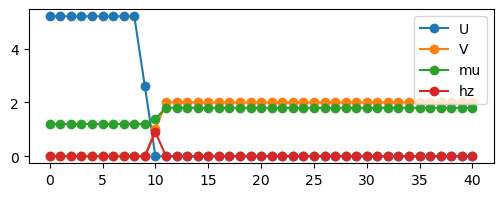

In [13]:
widthS = 10
widthF = 1
widthP = 30

X, Y = widthS+widthF+widthP, 200
lattice = Lattice(X, Y)

t = 1
T = 0.3

muS = 1.2 * t
muP = 1.8 * t
muF = 1.4 * t

mu = np.zeros(lattice.X)
mu[:widthS] = muS
mu[widthS:widthS + widthF] = muF
mu[widthS + widthF:] = muP

hz0 = 0.9 * t
hz = np.zeros_like(mu)
hz[widthS:widthS + widthF] = hz0

U0 = 5.2 * t
U = U0 * np.ones(lattice.X)
U[widthS:] = 0
U[widthS-1] = U0/2

V0 = 2 * t
V = V0 * np.ones(lattice.X)
V[:widthF+widthS] = 0
V[widthF+widthS-1] = V0/2

V_prime = None

plt.figure(figsize=(6,2))
if U is not None:
    plt.plot(U, '-o', label="U")
if V is not None:
    plt.plot(V, '-o', label="V")
if V_prime is not None:
    plt.plot(V_prime, '-o', label="V'",)
plt.plot(mu, '-o', label='mu')
plt.plot(hz, '-o', label='hz')

plt.legend()

In [14]:
H = Hamiltonian(
    t, mu, lattice,
    U=U, V_prime=V_prime, g_t=V,
    F0_init=0.1,
    F_init=[0.1, -0.1, 0.1j, -0.1j],
    hz=hz)

In [15]:
bdg_sc( H, maxiter=1000, temperature=T, rtol=0.001, atol=1e-6)
F, Fuu, Fdd = H.get_correlations()


Converged after 82 iterations


In [ ]:
temps = np.concatenate([
    np.arange(0.001, 0.009 + 1e-12, 0.001),
    np.arange(0.010, 0.100 + 1e-12, 0.001),
    np.arange(0.1005, 0.1400 + 1e-12, 0.0005),
    np.arange(0.141, 0.200 + 1e-12, 0.001),
])  # 240 temps total

print(len(temps))

print(temps)

240
[0.001  0.002  0.003  0.004  0.005  0.006  0.007  0.008  0.009  0.01
 0.011  0.012  0.013  0.014  0.015  0.016  0.017  0.018  0.019  0.02
 0.021  0.022  0.023  0.024  0.025  0.026  0.027  0.028  0.029  0.03
 0.031  0.032  0.033  0.034  0.035  0.036  0.037  0.038  0.039  0.04
 0.041  0.042  0.043  0.044  0.045  0.046  0.047  0.048  0.049  0.05
 0.051  0.052  0.053  0.054  0.055  0.056  0.057  0.058  0.059  0.06
 0.061  0.062  0.063  0.064  0.065  0.066  0.067  0.068  0.069  0.07
 0.071  0.072  0.073  0.074  0.075  0.076  0.077  0.078  0.079  0.08
 0.081  0.082  0.083  0.084  0.085  0.086  0.087  0.088  0.089  0.09
 0.091  0.092  0.093  0.094  0.095  0.096  0.097  0.098  0.099  0.1
 0.1005 0.101  0.1015 0.102  0.1025 0.103  0.1035 0.104  0.1045 0.105
 0.1055 0.106  0.1065 0.107  0.1075 0.108  0.1085 0.109  0.1095 0.11
 0.1105 0.111  0.1115 0.112  0.1125 0.113  0.1135 0.114  0.1145 0.115
 0.1155 0.116  0.1165 0.117  0.1175 0.118  0.1185 0.119  0.1195 0.12
 0.1205 0.121  0.1215 0.122  

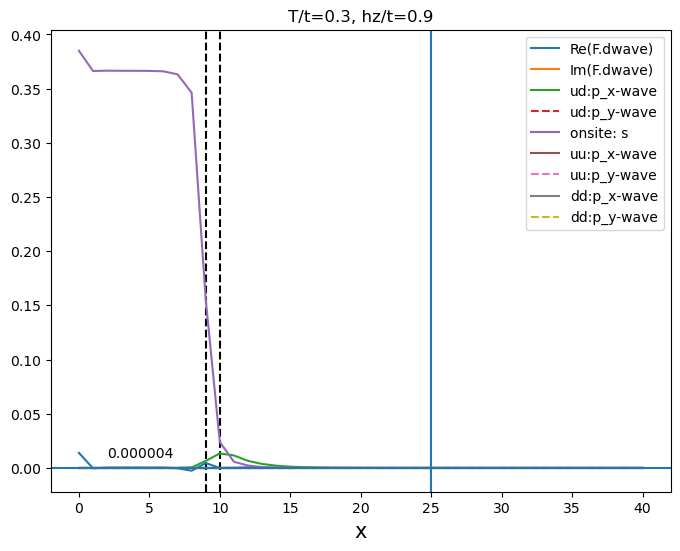

In [16]:
x = np.arange(0, widthS + widthF + widthP)

fig, axs = plt.subplots(1, 1, figsize=(8, 6))
axs.set_title(f"T/t={T}, hz/t={hz0}")
axs.axvline(int(widthS)-1, color='black', linestyle='--')
axs.axvline(widthS+widthF-1, color='black', linestyle='--')
axs.axvline(25)

axs.plot(x, np.real(F.dwave), label="Re(F.dwave)")
axs.plot(x, np.imag(F.dwave), label="Im(F.dwave)")
axs.plot(x, np.abs(F.px), label="ud:p_x-wave")
axs.plot(x, np.abs(F.py), "--", label="ud:p_y-wave")
axs.plot(x, np.abs(H.F0), label="onsite: s")
axs.plot(x, np.abs(Fuu.px), label="uu:p_x-wave")
axs.plot(x, np.abs(Fuu.py), "--", label="uu:p_y-wave")
axs.plot(x, np.abs(Fdd.px), label="dd:p_x-wave")
axs.plot(x, np.abs(Fdd.py), "--", label="dd:p_y-wave")
axs.set_xlabel("x", fontsize=15)
# axs.set_ylim(None, 0.1)
axs.axhline(np.abs(F.px)[25])
axs.text(2, np.abs(F.px)[25]+0.01, f"{np.abs(F.px)[25]:.6f}")
axs.legend()
# plt.show()

In [17]:
print(F.px[25])
print(F.py[25])

(-3.7621211452707125e-06+0j)
2.7901696569378888e-14j


In [18]:
from scripts.utils import is_hermitian

print(is_hermitian(H.build_H_k(np.pi/4)))
print(is_hermitian(H.build_H_kindep()))
print(is_hermitian(H.build_H_k0()))

True
True
True
